# Images are arrays: MNIST with NumPy

MNIST is a classic dataset of handwritten digits: 60,000 training images and 10,000 test images, each labelled with the digit it shows. Every image is a 28×28 grid of numbers, so a set of images is a NumPy array, and everything you do to images (scaling, adding noise, shifting, cropping) is array manipulation.

**How to work**

- Solve each exercise in the empty cell below it, adding cells if you need them. Use NumPy, and matplotlib only to plot.
- Keep the names the exercises ask for: the tests look for them. Check your work with the tests, as the [README](README.md#3-run-the-tests-they-fail) explains.
- Do a first pass **without an AI assistant**: the point is to learn how arrays behave, and you can only judge an assistant's answer once you know that. Then ask an assistant for another way to solve two of the exercises, time both versions, and write down which one is better and why.
- A solution that compares alternative approaches is in [mnist_numpy_solution.ipynb](mnist_numpy_solution.ipynb). Open it after trying.

## Loading MNIST

The images come from the [MNIST database](https://en.wikipedia.org/wiki/MNIST_database). Its authors **scaled** each black-and-white digit to fit a 20×20 box, keeping its proportions, which smoothed the edges into grey levels. Then they placed it in a 28×28 frame with its centre of mass at the centre. Each pixel is a grey level: a number from 0 to 255.

The dataset is downloaded as one `.npz` file, a zip of several NumPy arrays, from the address Keras uses. Its SHA-256 checksum is compared with the published one, so a corrupted download is detected. The file is kept in a `data/` folder that git ignores, so it is downloaded only once. `type ImagesAndLabels = ...` gives a name to a type, so that the signature of `load_mnist` stays readable.

In [ ]:
import hashlib
import urllib.request
from pathlib import Path

import numpy as np

MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
MNIST_SHA256 = "731c5ac602752760c8e48fbffcf8c3b850d9dc2a2aedcf2cc48468fc17b673d1"

type ImagesAndLabels = tuple[np.ndarray, np.ndarray]


def load_mnist(cache_dir: Path = Path("data")) -> tuple[ImagesAndLabels, ImagesAndLabels]:
    """Download MNIST into `cache_dir` once, check it, and return its (train, test) splits."""
    cache_dir.mkdir(exist_ok=True)
    path = cache_dir / "mnist.npz"
    if not path.exists():
        urllib.request.urlretrieve(MNIST_URL, path)
    if hashlib.sha256(path.read_bytes()).hexdigest() != MNIST_SHA256:
        path.unlink()
        raise ValueError("The download is corrupted and has been deleted: run the cell again")
    with np.load(path) as mnist:
        return (mnist["x_train"], mnist["y_train"]), (mnist["x_test"], mnist["y_test"])


(X_train, y_train), (X_test, y_test) = load_mnist()

`X_train` holds the training images and `y_train` their **labels**. The usual convention in machine learning is a capital `X` for the inputs, because they usually form a matrix with one row per sample and one column per feature, and a lowercase `y` for the targets, a vector with one value per sample. Here `X_train` has three dimensions, one 28×28 image per sample; exercise 2 turns it into that matrix.

In [ ]:
type(X_train), X_train.dtype, X_train.shape

(numpy.ndarray, dtype('uint8'), (60000, 28, 28))

A NumPy array of 60,000 images of 28×28 pixels: three dimensions. Its type is `uint8`, an unsigned 8-bit integer, so every pixel is an integer from 0 to 255, where 0 is the background and 255 the darkest ink. At one byte per pixel, the whole training set takes about 47 MB.

In [ ]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

The labels are the digits 0 to 9, one per image. The first image, as numbers:

In [ ]:
def print_pixel_values(image: np.ndarray) -> None:
    for row in image:
        print("".join(f"{pixel:4}" for pixel in row))


print_pixel_values(X_train[0])

   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0
   0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0
   0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0
   0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247 241   0   0   0   0   0   0

and in a more elegant way, using the **matplotlib** library:

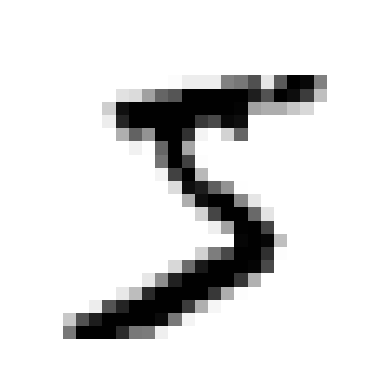

In [ ]:
import matplotlib.pyplot as plt


def plot_image(image: np.ndarray) -> None:
    plt.imshow(image, cmap="binary")
    plt.axis("off")
    plt.show()


plot_image(X_train[0])

The colour map decides how numbers become colours. With `cmap="binary"`, 0 is drawn white and 255 black, like ink on paper; with `cmap="gray"`, the same array shows a white digit on a black background. The array doesn't change, only its picture.

In [ ]:
y_train[0]

np.uint8(5)

The first 100 training images:

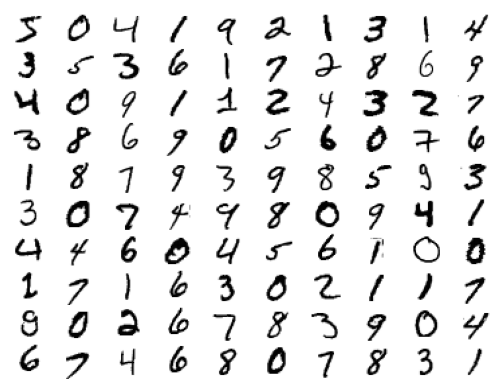

In [ ]:
def plot_first_100(images: np.ndarray) -> None:
    for index, image in enumerate(images[:100]):
        plt.subplot(10, 10, index + 1)
        plt.imshow(image, cmap="binary")
        plt.axis("off")
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()


plot_first_100(X_train)

## Exercises

### Shapes and indexing

**1.** Create `matrix_first_100_labels`, a 10×10 array with the first 100 labels, and display it. It should match the grid of images above.

**2.** Many models expect each example as one flat row of numbers: each 28×28 image becomes a vector of 784 pixels. Create `X_train_flat` and `X_test_flat`, with shapes 60,000×784 and 10,000×784.

**3.** Change `plot_image` so that it accepts both a 28×28 image and a flat row of 784 pixels. Check it with `X_train_flat[0]`.

**4.** Check, with one expression and no loop, that the bottom-right pixel is 0 in every training image.

**5.** Does any digit touch the edge of its frame? Store in `n_touching_border` the number of training images with ink (a non-zero pixel) in their first or last row or column.

### Data types

**6.** Compute `X_train[0] + X_train[0]` and look at its maximum. Then compute the same sum correctly, and store in `n_overflowed_pixels` the number of pixels where the two results differ. Why do they differ?

### One-hot encoding

**7.** Some models expect each label as a ***one-hot* vector**: ten numbers, all 0 except a 1 at the position of the digit. Label 5 becomes `[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]`. Create `y_train_onehot` and `y_test_onehot`.

### Normalisation and standardisation

**8.** Display the minimum, maximum, mean and standard deviation of the pixels of the training images.

**9.** Scale the training images to the range [0, 1] as `X_train_norm`, of type `float32`, and plot its first image.

**10.** Store in `pixel_norm_mean` and `pixel_norm_std` the mean and the standard deviation of the pixels of `X_train_norm`. You will meet these two numbers again.

**11.** *Standardise* the images: subtract the mean and divide by the standard deviation, so that the pixels have mean 0 and standard deviation 1.

$$X_{std} = \frac{X - \mu}{\sigma}$$

Create `X_train_standardized` and `X_test_standardized`. Compute μ and σ on the **training** images only, and use those same two numbers for the test images.

**12.** Standardise `X_train_norm`, the images scaled to [0, 1], the same way, as `X_train_norm_standardized`. Check with `np.allclose` that it equals `X_train_standardized`. Why must they be equal?

### Loops and vectorisation

**13.** Write `normalize_with_loops(images)`, which scales the images to [0, 1] with Python loops over every pixel, as you would without NumPy. Time it against `images / 255` on the first 1,000 training images with `time.perf_counter`, and store in `speedup` how many times faster the vectorised version is. The `compare-python-c-efficiency` repository explains where the difference comes from.

### Data augmentation

*Data augmentation* creates new training examples by transforming the ones you have: a digit shifted a few pixels, or with some noise, is still the same digit. A model trained on the augmented set sees more variety and generalises better. Deep-learning libraries do it for you; here you do it by hand.

**14.** Write `add_gaussian_noise(images, std)`, which adds random noise from a normal distribution with mean 0 and standard deviation `std` to every pixel, and returns images of the same type and range as the input (`uint8`, 0 to 255). Create `X_train_noisy` with `std=50`, and plot the first 100 images.

> **Gaussian noise is random noise that follows a normal distribution.** It can be applied to images to simulate non-ideal image capture conditions. This can help make machine learning models more robust.
>
> `rng = np.random.default_rng(seed=0)` gives you a random generator, and `rng.normal` draws numbers from a normal distribution. The seed makes the noise the same every time you run the notebook.

**15.** Write `binarize_image(image, threshold)`, which returns 1 where a pixel is greater than `threshold` and 0 elsewhere, as `uint8`. It must work for one image and for a whole array of images. Create `X_train_binarized` with threshold 128 and plot the first 100 images.

**16.** Plot the first 100 training images binarised with thresholds 80 and 180, one cell each. What changes?

**17.** Create `X_train_noisy_binarized` by binarising the noisy images with threshold 128, and plot the first 100. Try other thresholds: which one removes most of the noise without breaking the digits?

**18.** Write `shift_image(image, dx, dy)`, which moves an image `dx` pixels to the right (to the left if negative) and `dy` pixels down (up if negative), filling the space left behind with 0. Plot the first image shifted 10 pixels in each of the four directions, one cell each.

**19.** Create `X_train_shifted_right_10` with every training image shifted 10 pixels to the right, and plot the first 100. Some digits are cut: which ones, and why?

**20.** Write `find_limits(image)`, which returns `(top, bottom, left, right)`: the first and last rows and columns that contain ink. Check that the first training image gives `(5, 24, 4, 23)`. Then plot it with its limits drawn as lines (`plt.axhline` and `plt.axvline`).

**21.** Write `crop_image_limits(image)`, which returns the image cropped to its limits. What shape is the first training image once cropped, and why? Remember how MNIST was built.

**22.** Create `X_train_shifted`: every training image shifted by a random amount in each direction, but never so far that ink leaves the frame. Use `find_limits` to know how far each digit can move.

**23.** Create `X_train_augmented` by joining, in this order, the original training images, the noisy ones, the binarised ones, the noisy and binarised ones, and the randomly shifted ones. Scale the two binarised sets back to 0 and 255 first, so that all the images share one range. Create `y_train_augmented` with the matching labels. How many images are there?

### Going further

**24.** *(Optional, no test.)* Building `X_train_shifted` calls a Python function 60,000 times. Write a version without a loop over the images, and measure the speed-up. Is it worth it? Hint: pad the whole array with zeros once, then take for each image the 28×28 window that matches its offset, with fancy indexing.